# Model and Wrapper

## Model

In [2]:
from torch import nn
from typing import Literal

class MLPClassifier(nn.Module):
    def __init__(self, n_hidden:int, hidden_dim:int, input_dim:int, output_dim:int, activation:Literal['ReLU', 'Tanh'] = 'ReLU'):
        super(MLPClassifier, self).__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(n_hidden)])
        self.output_layer = nn.Linear(hidden_dim, output_dim)

        if activation == 'ReLU':
            self.activation = nn.ReLU()
        elif activation == 'Tanh':
            self.activation = nn.Tanh()
        else:
            raise ValueError(f"Unknown activation function: {activation}")

    def forward(self, input):
        x = self.activation(self.input_layer(input))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        x = self.output_layer(x)

        return x.squeeze(1) if x.shape[-1] == 1 else x

## Wrapper

In [1]:
import numpy as np
from torch.nn.utils import clip_grad_norm_
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.metrics import accuracy_score

class MyWrapper(ClassifierMixin, BaseEstimator):
    def __init__(self, model, classes:list | np.ndarray, lr:float=1e-3, epochs:int=50, batch_size:int=None, device:torch.device=None, is_fitted:bool = False):
        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = device

        self.model = model.to(self.device)
        self.classes = classes
        self.classes_ = classes

        self.batch_size = batch_size
        self.epochs = epochs
        self.lr = lr
        self.is_fitted  = is_fitted


    def fit(self, X: np.ndarray, y: np.ndarray, sample_weight=None) -> float:
        def _train_one_epoch(model, loader, optimizer, criterion, max_norm:float=1.0):
            model.train()
            running_loss = 0.0
            for X, y in loader:
                X, y = X.to(self.device), y.to(self.device)
                optimizer.zero_grad()
                loss = criterion(model(X), y)
                running_loss += loss.item()
                loss.backward()
                clip_grad_norm_(model.parameters(), max_norm=max_norm)
                optimizer.step()
            avg_loss = running_loss / len(loader)

            return avg_loss

        self.model.to(self.device)
        optimzer = torch.optim.Adam(self.model.parameters(), lr=self.lr)

        if len(self.classes) == 2:
            criterion = nn.BCEWithLogitsLoss()
            y_tensor = torch.Tensor(y).to(self.device)

        else:
            criterion = nn.CrossEntropyLoss()
            y_tensor = torch.Tensor(y).long().to(self.device)

        X_tensor = torch.Tensor(X).to(self.device)

        if sample_weight is not None:
            sampler = WeightedRandomSampler(sample_weight, len(X_tensor), replacement=True)
        else:
            sampler = None

        train_loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=self.batch_size, sampler=sampler)

        running_loss = 0.0
        for epoch in range(self.epochs):
            running_loss += _train_one_epoch(self.model, train_loader, optimzer, criterion)

        print(f'Avrage Loss {running_loss/self.epochs}')

        self.is_fitted = True
        return self


    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        X_tensor = torch.Tensor(X).to(self.device)

        self.model.eval()
        output = self.model(X_tensor)

        if len(self.classes) == 2:
            proba = torch.sigmoid(output).detach().cpu().numpy()
            proba = proba.reshape(-1, 1)
            proba = np.hstack([1 - proba, proba])
        else:
            proba = torch.softmax(output, dim=1).detach().cpu().numpy()


        return proba

    def predict(self, X: np.ndarray) -> np.ndarray:
        proba = self.predict_proba(X)

        if len(self.classes) == 2:
            preds = self.classes[(proba[:, 1] >= 0.5).astype(int)]
        else:
            preds = self.classes[proba.argmax(axis=1)]

        return preds


    def score(self, X, y, sample_weight=None):
        check_is_fitted(self, attributes=["is_fitted"])
        y_pred = self.predict(X)

        return accuracy_score(y, y_pred, sample_weight=sample_weight)


## Report Function

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, RocCurveDisplay, classification_report, confusion_matrix
import numpy as np
import warnings

# Suppress all FutureWarnings
warnings.filterwarnings("ignore")


def report(model:MyWrapper, X: np.ndarray, target: np.ndarray, classes: list):
    """
    Generates a classification report, confusion matrix, and ROC curves
    by generating predictions directly from the provided model and features.
    """
    # Generate predictions inside the function
    y_proba = model.predict_proba(X)
    y_pred = model.predict(X)

    fig, ax = plt.subplots(1, 2, figsize=(20, 6))
    ax = ax.flatten()

    # 1. Confusion Matrix
    cf_mtx = confusion_matrix(target, y_pred)
    sns.heatmap(cf_mtx, annot=True, fmt="g", ax=ax[0])
    ax[0].set_title('Confusion Matrix')
    ax[0].set_xticklabels(classes)
    ax[0].set_yticklabels(classes)

    # 2. Multiclass ROC Curve (One-vs-Rest)
    for idx in range(len(classes)):
        fpr, tpr, thresholds = roc_curve(target == idx, y_proba[:, idx])
        roc_auc = auc(fpr, tpr)
        display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
        display.plot(ax=ax[1])

    ax[1].plot([0, 1], [0, 1], color='white', linestyle='--')
    ax[1].set_title('Multiclass ROC Curve (One-vs-Rest)')

    plt.legend(classes)
    plt.show()

    # 3. Text Classification Report
    clf_r = classification_report(target, y_pred, target_names=[str(c) for c in classes])
    print(clf_r)

# Data

In [5]:
from sklearn.model_selection import train_test_split
import pandas as pd
import os


path = os.path.join('Data', 'test.csv')
data = pd.read_csv(path)

target_name = 'NObeyesdad'
X, y = data.drop([target_name], axis=1), data[target_name]


print(f'test set: {len(y)}')

test set: 4152


# Model and Classifcation report


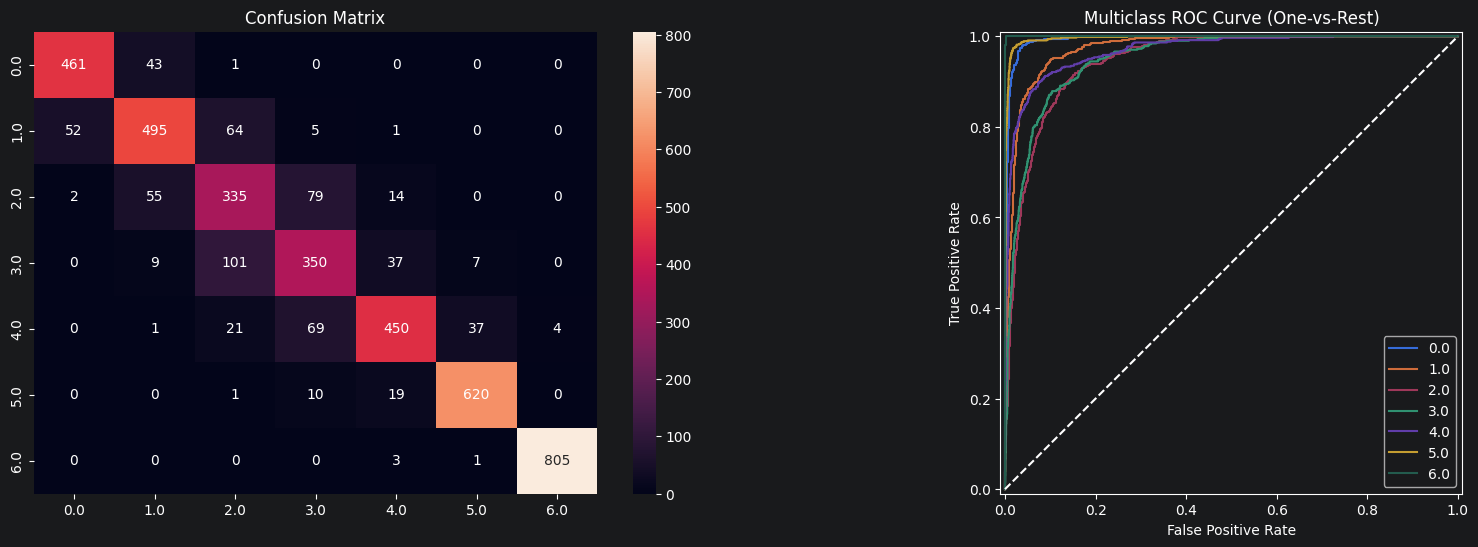

              precision    recall  f1-score   support

         0.0       0.90      0.91      0.90       505
         1.0       0.82      0.80      0.81       617
         2.0       0.64      0.69      0.66       485
         3.0       0.68      0.69      0.69       504
         4.0       0.86      0.77      0.81       582
         5.0       0.93      0.95      0.94       650
         6.0       1.00      1.00      1.00       809

    accuracy                           0.85      4152
   macro avg       0.83      0.83      0.83      4152
weighted avg       0.85      0.85      0.85      4152



In [7]:
model_path = os.path.join('Models', 'NotCalibrated', 'last.ckpt')
checkpoint = torch.load(model_path, map_location=lambda storage, loc: storage)

X_np = X.to_numpy()
y_np = y.to_numpy()

model_config = checkpoint["hyper_parameters"]
model_config.pop('lr')

raw_state_dict = checkpoint['state_dict']
clean_state_dict = {k.replace('model.', ''): v for k, v in raw_state_dict.items()}

model = MLPClassifier(**model_config)
model.load_state_dict(clean_state_dict)

sorted_classes = np.sort(y.unique())
wrappedModel = MyWrapper(model, classes=sorted_classes, is_fitted=True, device=torch.device('cpu'))
report(wrappedModel, X_np, y_np, classes=sorted_classes)

# XAI - What influences model decision?

## Feature Permutation
with Confidence Intervals

In [10]:
from sklearn.inspection import permutation_importance
print(f"\n--- Permutation Importance ---")
significant_features = []

for i in range(X.shape[1]):
    result = permutation_importance(wrappedModel, X_np, y_np, n_repeats=100, random_state=0, scoring='accuracy')
    mean = result.importances_mean[i]
    std = result.importances_std[i]

    # Wyznaczenie 95% przedziału ufności dla średniej
    margin_of_error = 1.96 * (std / np.sqrt(100))
    ci_lower = mean - margin_of_error
    ci_upper = mean + margin_of_error

    if ci_upper < 0 or ci_lower > 0:
        significant_features.append((i, mean, ci_lower, ci_upper))
        print(f"Cecha {i}: Mean={mean:.4f}, CI=[{ci_lower:.4f}, {ci_upper:.4f}]")


--- Permutation Importance ---
Cecha 0: Mean=0.0071, CI=[0.0068, 0.0075]
Cecha 1: Mean=0.0279, CI=[0.0273, 0.0285]
Cecha 2: Mean=0.0255, CI=[0.0249, 0.0260]
Cecha 3: Mean=0.0086, CI=[0.0080, 0.0091]
Cecha 4: Mean=0.0049, CI=[0.0045, 0.0052]
Cecha 5: Mean=0.0904, CI=[0.0895, 0.0913]
Cecha 6: Mean=0.5781, CI=[0.5767, 0.5795]
Cecha 7: Mean=0.1732, CI=[0.1722, 0.1742]
Cecha 8: Mean=0.0079, CI=[0.0075, 0.0082]
Cecha 9: Mean=0.0264, CI=[0.0259, 0.0269]


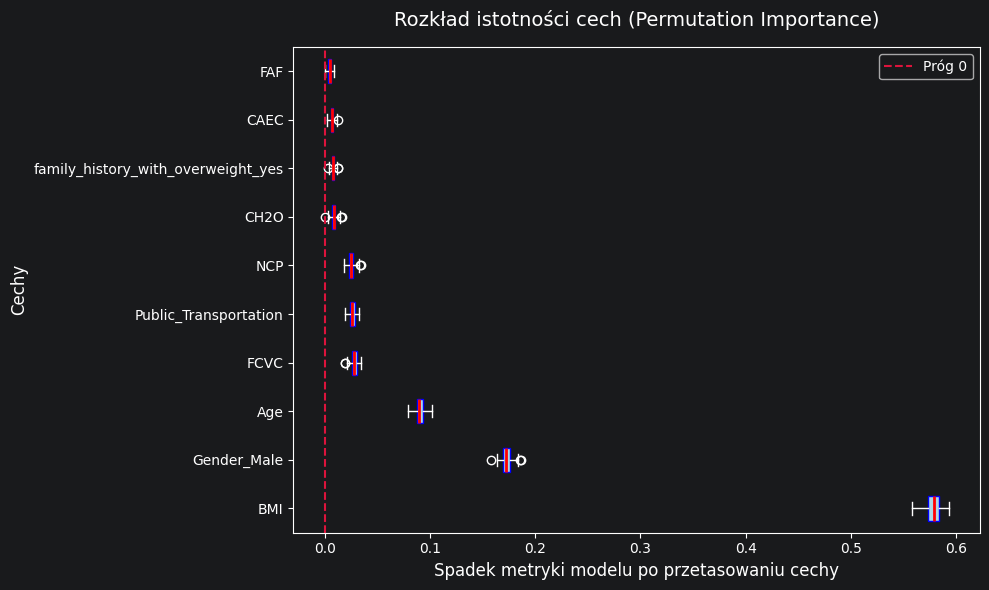

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

feature_names = (
    X.columns
    if hasattr(X, "columns")
    else [f"Cecha {i}" for i in range(X.shape[1])]
)


sorted_importances_idx = result.importances_mean.argsort()[::-1]
sorted_feature_names = [feature_names[i] for i in sorted_importances_idx]
sorted_importances = result.importances[sorted_importances_idx]

plt.figure(figsize=(10, 6))

plt.boxplot(
    sorted_importances.T,
    vert=False,
    labels=sorted_feature_names,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="blue"),
    medianprops=dict(color="red", linewidth=2),
)

plt.axvline(x=0, color="crimson", linestyle="--", linewidth=1.5, label="Próg 0")

plt.title("Rozkład istotności cech (Permutation Importance)", fontsize=14, pad=15)
plt.xlabel("Spadek metryki modelu po przetasowaniu cechy", fontsize=12)
plt.ylabel("Cechy", fontsize=12)
plt.legend(loc="upper right")
plt.tight_layout()

plt.show()

## LIME
Local Inpretable Model-agnostic Explanations

In [28]:
import numpy as np
import statsmodels.api as sm
import pandas as pd

def explain_instance_wls(X_to_explain, X_train_reference, predict_fn, num_classes,
                         num_of_perturbations=1000, pert_factor=0.3, seed=42):
    """
    Explains a single multiclass prediction by fitting a separate WLS model for each class.

    Parameters:
    -----------
    predict_fn : callable
        Should return predicted probabilities, e.g., model.predict_proba.
        Output shape must be (num_of_perturbations, num_classes).
    num_classes : int
        The total number of target classes in your dataset.
    """
    rng = np.random.default_rng(seed)

    # 1. Calculate standard deviations from reference training data
    stds = np.std(X_train_reference, axis=0)

    # 2. Generate Gaussian noise scaled by stds and perturbation factor
    noise = rng.normal(0, 1, size=(num_of_perturbations, X_to_explain.shape[0]))
    noise = noise * stds * pert_factor

    # 3. Create perturbed samples around the instance
    perturbations = X_to_explain + noise

    # 4. Get multiclass probability outputs
    # Expected shape: (num_of_perturbations, num_classes)
    y_probabilities = predict_fn(perturbations)

    # 5. Compute distances and convert to weights using an exponential kernel
    euclidean_distances = np.linalg.norm(perturbations - X_to_explain, axis=1)
    kernel_width = np.sqrt(X_to_explain.shape[0]) * 0.75
    distances = np.exp(-(euclidean_distances ** 2) / (kernel_width ** 2))

    # 6. Fit a separate surrogate Weighted Least Squares (WLS) model for each class
    X_lime = sm.add_constant(perturbations)
    class_models = {}

    for class_idx in range(num_classes):
        # Target variable is the probability column belonging to this specific class
        y_class = y_probabilities[:, class_idx]

        wls_model = sm.WLS(y_class, X_lime, weights=distances)
        class_models[class_idx] = wls_model.fit()

    return class_models  # Returns a dictionary: {class_index: fitted_wls_model}

def explain_dataset_global(X_explain_set, X_train_reference, predict_fn, feature_names, num_classes,
                           sample_size=None, num_of_perturbations=1000, pert_factor=0.3, seed=42):
    """
    Aggregates local WLS-LIME multiclass explanations into a single global
    feature importance ranking (not split by class).
    """
    rng = np.random.default_rng(seed)

    # 1. Handle DataFrame vs Numpy Array slicing safely
    if sample_size and sample_size < len(X_explain_set):
        indices = rng.choice(len(X_explain_set), size=sample_size, replace=False)
        X_to_process = X_explain_set.iloc[indices].values if hasattr(X_explain_set, "iloc") else X_explain_set[indices]
    else:
        X_to_process = X_explain_set.values if hasattr(X_explain_set, "values") else X_explain_set

    # List to collect absolute coefficients across ALL instances and ALL classes
    all_abs_coefficients = []

    print(f"Calculating local explanations for {len(X_to_process)} instances across {num_classes} classes...")

    # 2. Loop through instances
    for i, instance in enumerate(X_to_process):
        local_results = explain_instance_wls(
            X_to_explain=instance,
            X_train_reference=X_train_reference,
            predict_fn=predict_fn,
            num_classes=num_classes,
            num_of_perturbations=num_of_perturbations,
            pert_factor=pert_factor,
            seed=seed + i
        )

        # 3. For the current instance, extract coefficients for EVERY class
        for class_idx in range(num_classes):
            # Exclude intercept at index 0 and take the absolute value
            abs_coefs = np.abs(local_results[class_idx].params[1:])
            all_abs_coefficients.append(abs_coefs)

    # 4. Convert all collected coefficients into one unified DataFrame
    df_all_coefs = pd.DataFrame(all_abs_coefficients, columns=feature_names)

    # 5. Average everything together to get a single global importance score per feature
    global_importance = df_all_coefs.mean().sort_values(ascending=False)

    # Wrap it nicely in a summary DataFrame
    global_summary = pd.DataFrame({
        'Global Importance (Mean Abs)': global_importance
    })
    global_summary.index.name = 'Feature'

    return global_summary

## Global

In [29]:
global_lime_report = explain_dataset_global(
    X_explain_set=X.values,
    X_train_reference=X.values,
    predict_fn=wrappedModel.predict_proba,
    num_classes=7,
    feature_names=feature_names,
    sample_size=100,
    num_of_perturbations=500
)


global_lime_report

Calculating local explanations for 100 instances across 7 classes...


,Global Importance (Mean Abs)
Feature,
BMI,0.320184
Gender_Male,0.054503
Public_Transportation,0.043219
CAEC,0.033103
NCP,0.032450
FAF,0.031849
family_history_with_overweight_yes,0.031673
Age,0.028888
FCVC,0.028783


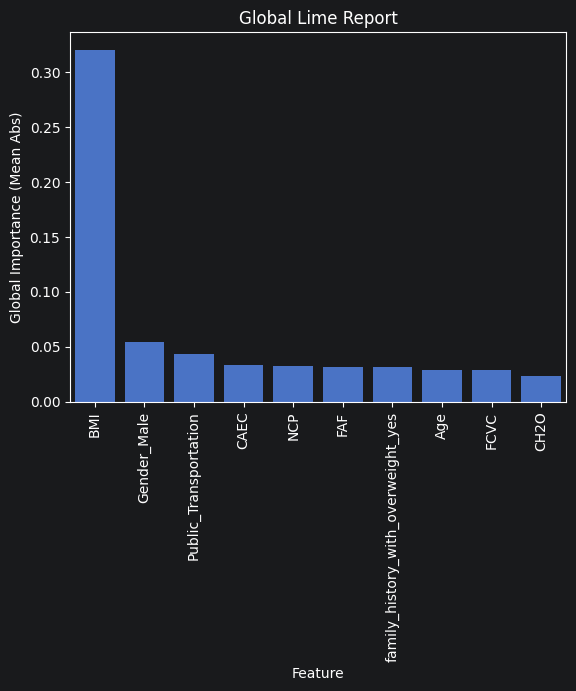

In [33]:
sns.barplot(global_lime_report, x='Feature', y='Global Importance (Mean Abs)')
plt.title("Global Lime Report")
plt.xticks(rotation=90)
plt.show()

## Explain by instance

### Top 5 most Certian

Explaining Sample no. 104, Classified as: 3.0


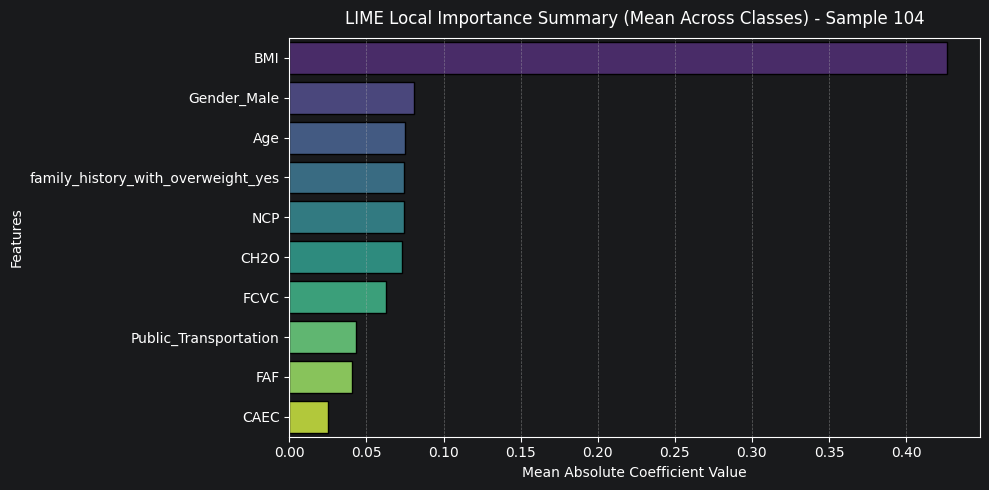

Explaining Sample no. 653, Classified as: 0.0


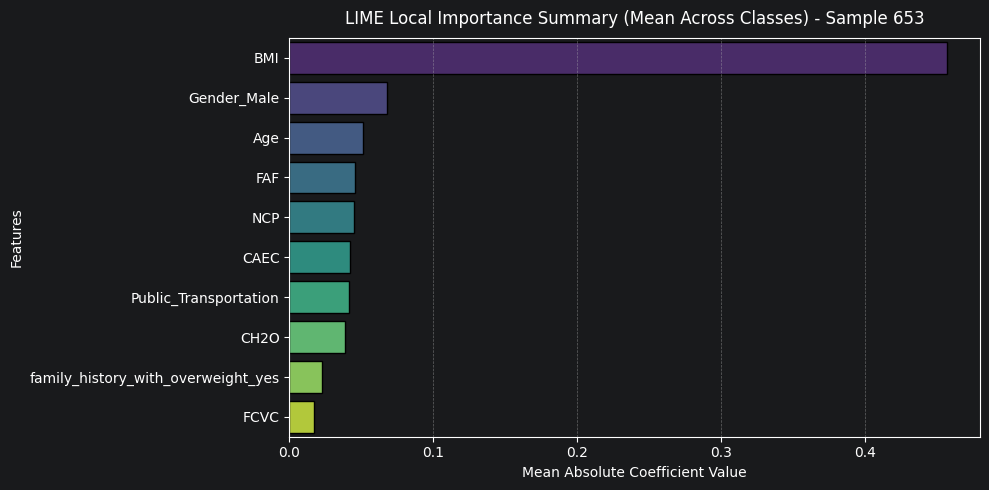

Explaining Sample no. 249, Classified as: 4.0


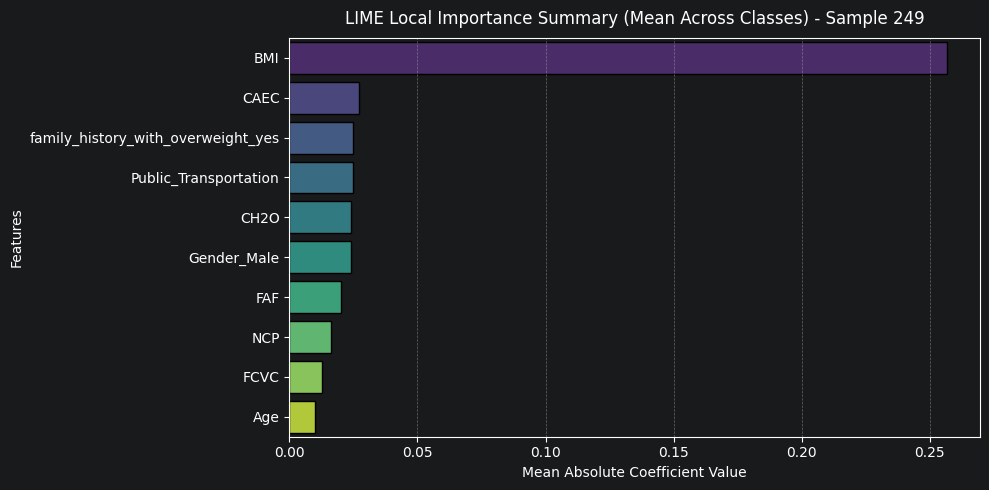

Explaining Sample no. 489, Classified as: 3.0


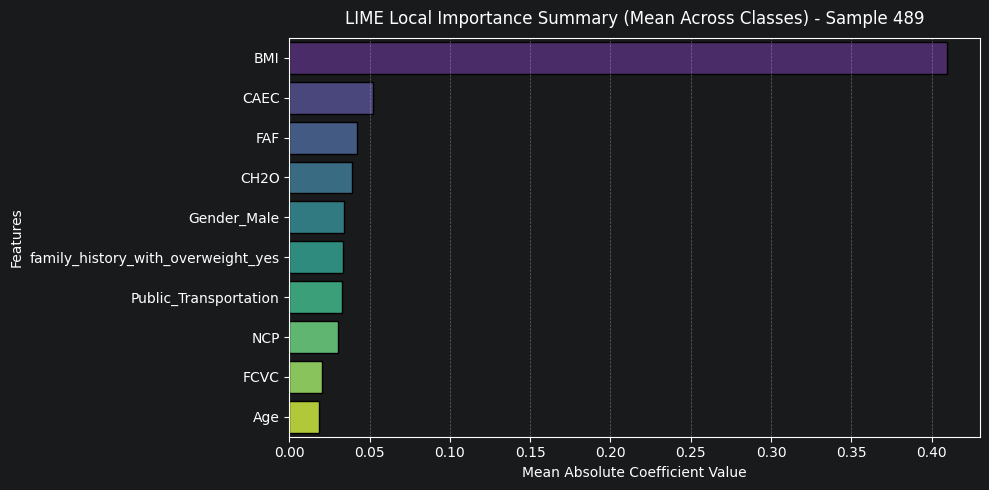

Explaining Sample no. 329, Classified as: 1.0


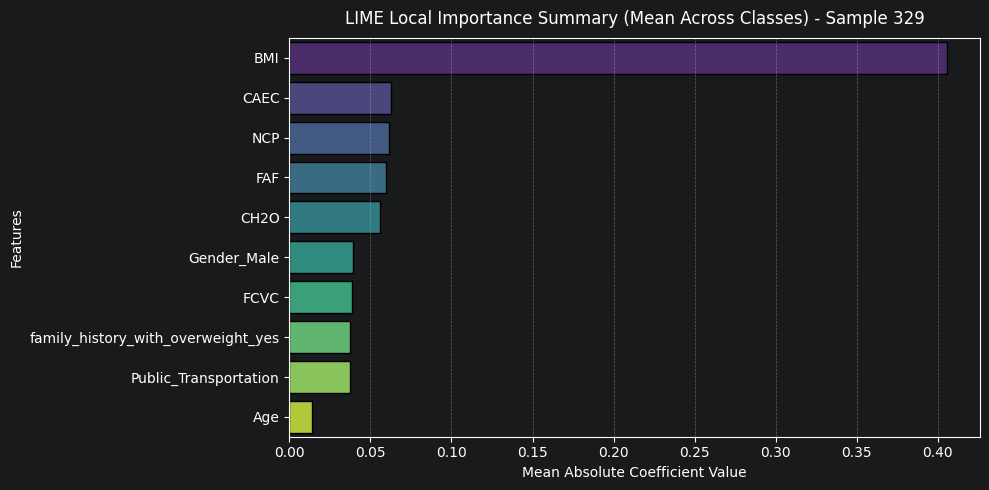

In [53]:
top_5_idx = [104, 653, 249, 489, 329]
for idx in top_5_idx:
    print(f'Explaining Sample no. {idx}, Classified as: {y[idx]}')
    local_models = explain_instance_wls(X_to_explain=X_np[idx],
                                  X_train_reference=X_np,
                                    predict_fn=wrappedModel.predict_proba,
                                    num_classes=7,
                                    num_of_perturbations=500)

    all_local_abs_coefs = []

    for class_idx in range(7):
        # Exclude intercept at index 0 and take absolute value
        abs_coefs = np.abs(local_models[class_idx].params[1:])
        all_local_abs_coefs.append(abs_coefs)

    # 4. Create a DataFrame where each row is a class and columns are features
    df_local_classes = pd.DataFrame(all_local_abs_coefs, columns=feature_names)

    # 5. Take the mean across all classes (rows) to find overall local importance
    mean_local_importance = df_local_classes.mean().sort_values(ascending=False)

    # 6. Construct a final summary table for this specific instance
    instance_summary = pd.DataFrame({
        'Feature Value': X_np[idx],
        'Local Importance (Mean Abs Across Classes)': df_local_classes.mean()
    }, index=feature_names).reindex(mean_local_importance.index)

    plt.figure(figsize=(10, 5))

    # 2. Corrected seaborn call to use a horizontal layout (highly readable)
    sns.barplot(
        data=instance_summary,
        x='Local Importance (Mean Abs Across Classes)',
        y=instance_summary.index,  # Use index for clean y-axis labels
        palette='viridis',
        edgecolor='black'
    )

    # 3. Add context-rich titles and labels
    plt.title(f"LIME Local Importance Summary (Mean Across Classes) - Sample {idx}", fontsize=12, pad=10)
    plt.xlabel("Mean Absolute Coefficient Value")
    plt.ylabel("Features")
    plt.grid(axis='x', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()



### Top 5 uncertian

Explaining Sample no. 188, Classified as: 6.0


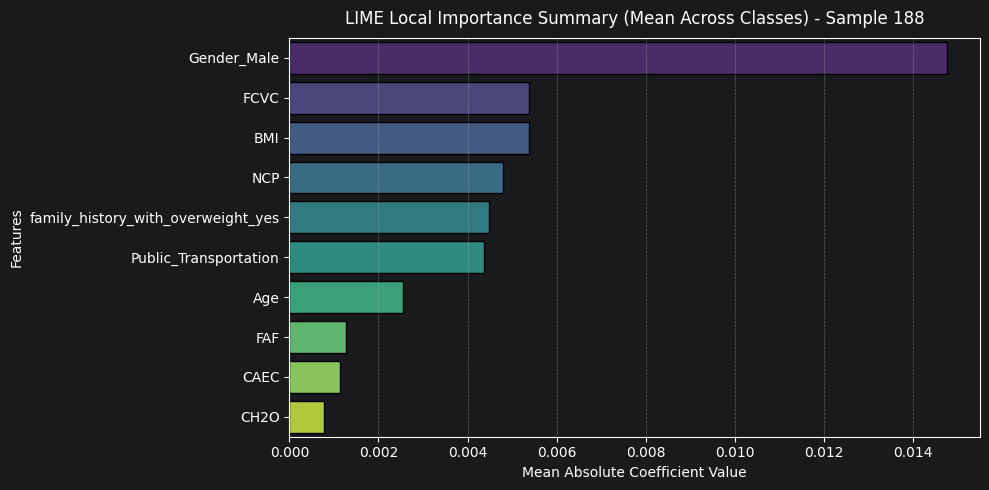

Explaining Sample no. 38, Classified as: 3.0


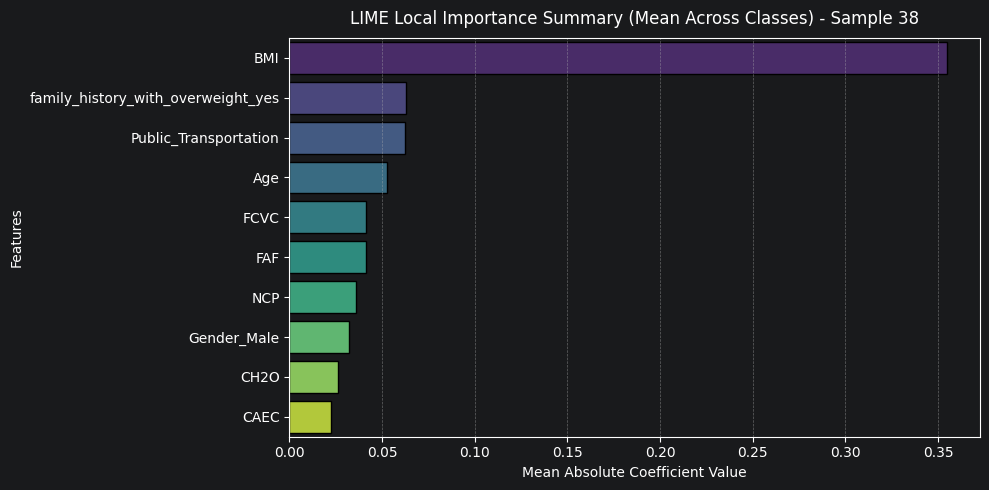

Explaining Sample no. 535, Classified as: 3.0


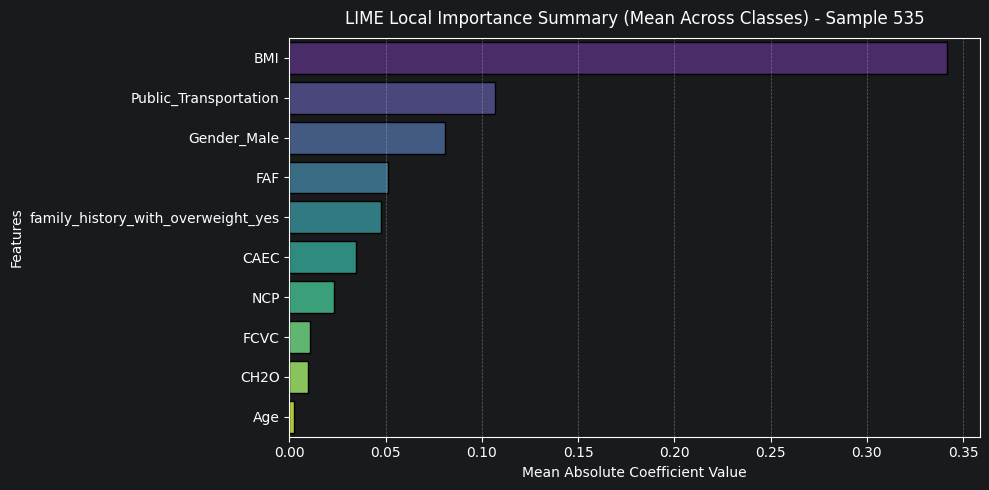

Explaining Sample no. 284, Classified as: 3.0


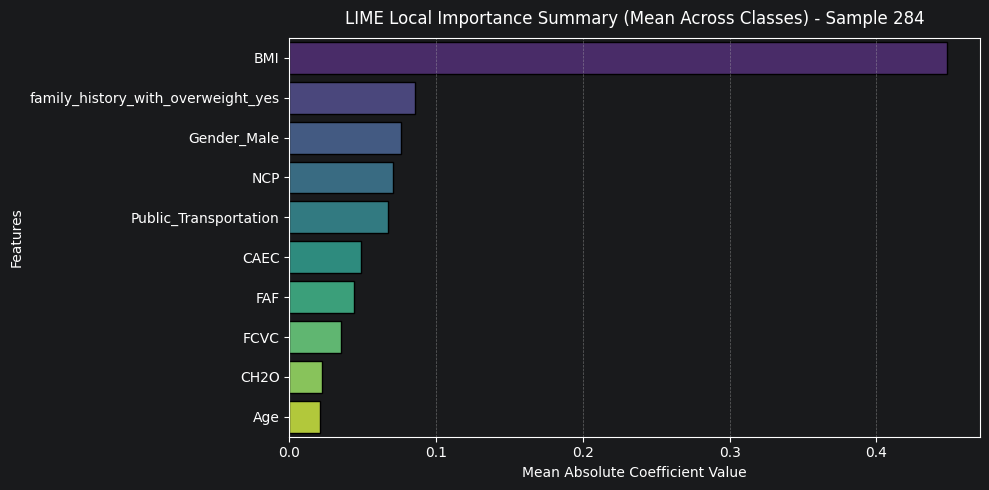

Explaining Sample no. 27, Classified as: 3.0


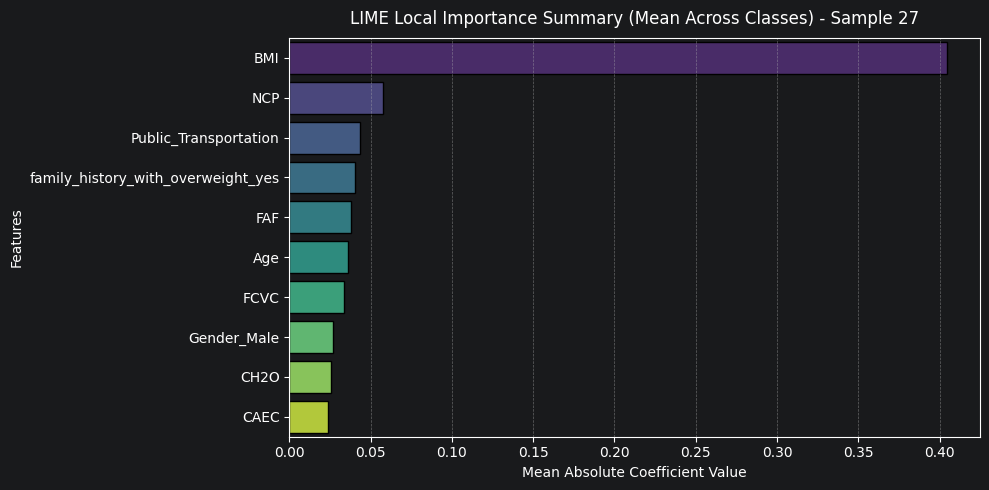

In [54]:
top_5_idx = [188, 38, 535, 284, 27]
for idx in top_5_idx:
    print(f'Explaining Sample no. {idx}, Classified as: {y[idx]}')
    local_models = explain_instance_wls(X_to_explain=X_np[idx],
                                  X_train_reference=X_np,
                                    predict_fn=wrappedModel.predict_proba,
                                    num_classes=7,
                                    num_of_perturbations=500)

    all_local_abs_coefs = []

    for class_idx in range(7):
        # Exclude intercept at index 0 and take absolute value
        abs_coefs = np.abs(local_models[class_idx].params[1:])
        all_local_abs_coefs.append(abs_coefs)

    # 4. Create a DataFrame where each row is a class and columns are features
    df_local_classes = pd.DataFrame(all_local_abs_coefs, columns=feature_names)

    # 5. Take the mean across all classes (rows) to find overall local importance
    mean_local_importance = df_local_classes.mean().sort_values(ascending=False)

    # 6. Construct a final summary table for this specific instance
    instance_summary = pd.DataFrame({
        'Feature Value': X_np[idx],
        'Local Importance (Mean Abs Across Classes)': df_local_classes.mean()
    }, index=feature_names).reindex(mean_local_importance.index)

    plt.figure(figsize=(10, 5))

    # 2. Corrected seaborn call to use a horizontal layout (highly readable)
    sns.barplot(
        data=instance_summary,
        x='Local Importance (Mean Abs Across Classes)',
        y=instance_summary.index,  # Use index for clean y-axis labels
        palette='viridis',
        edgecolor='black'
    )

    # 3. Add context-rich titles and labels
    plt.title(f"LIME Local Importance Summary (Mean Across Classes) - Sample {idx}", fontsize=12, pad=10)
    plt.xlabel("Mean Absolute Coefficient Value")
    plt.ylabel("Features")
    plt.grid(axis='x', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

